[60, 65, 70, 75, 80, 85, 90, 95]
[0.8518881804806278, 0.8806376360808709, 0.8872614292055038, 0.896832191780822, 0.8911439114391144, 0.918867202449292, 0.8859717868338558, 0.9135506003430531]


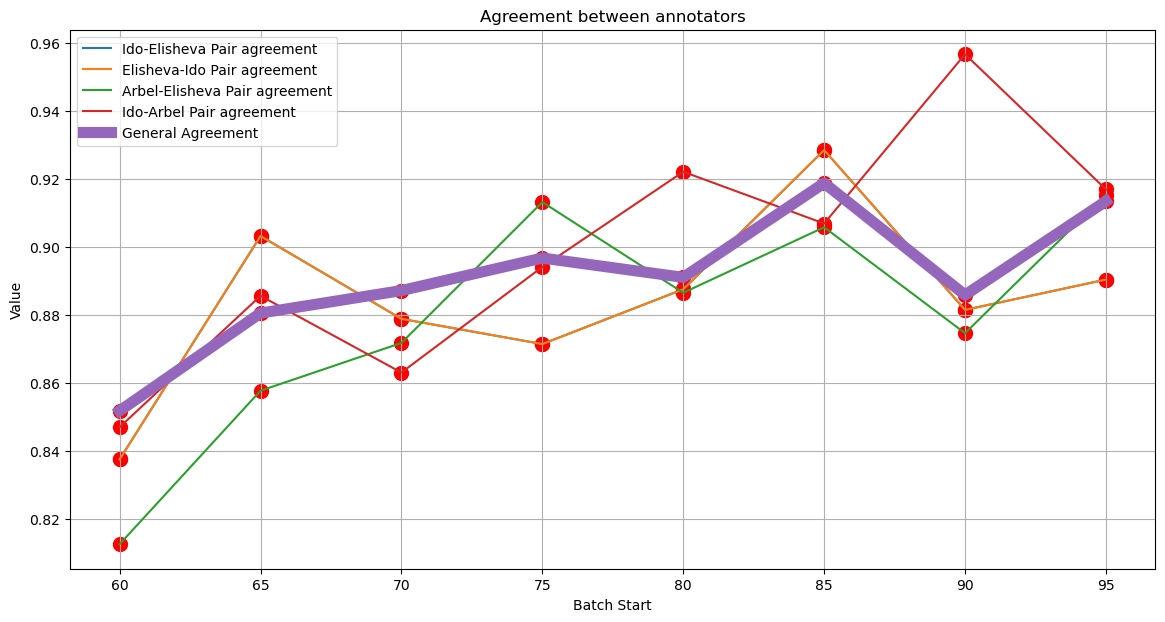

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from mention_agreemnet_utils import process_annotations, read_annotation_data

start = 60
end = 96
conllu_annotated_files_path = "../../mention_annotation_data"

# Define the annotator pairs
annotator_pairs = [('Ido', 'Elisheva'), ('Elisheva', 'Ido'), ('Arbel', 'Elisheva'), ('Ido', 'Arbel')]

# Initialize an empty dictionary to store counts
counts_dict = {pair: [] for pair in annotator_pairs}

# List to store general agreement data points
general_agreement = []
# Loop over batches of 5 starting from start to 100
for i in range(start, end, 5):
    specific_files = set(list(range(i, i + 5)))  # Define specific files

    # Read the annotation data
    file_by_annotator = read_annotation_data(conllu_annotated_files_path, specific_files=specific_files,
                                             exclude={'ariela levkov', 'Ariela', 'Yeshaaya Klein', 'Hadas Elitzur',
                                                      'Bar Shwarts', 'Nofar Eidlman', 'itay atal', 'Hadar', 'may green',
                                                      'Shay Umaschi', 'Hadas', 'matan schwartz', 'Tal Bacalu',
                                                      'tsofit hadad', 'Odelia Tamayev', 'Tal Chayen', 'Hinoy',
                                                      'Yovelarye',
                                                      'אוריאל אטווד', 'Tal', 'Yechiel', 'shachar sasson', 'Noa Nagary',
                                                      'Shimrit Devora Laufer', 'Hadar Salniker', 'Shira Cohen',
                                                      'Ayala Dvir', 'Aviv Sason', 'Shali Bernstein', 'Itamar Adoram',
                                                      'yechiel hexter', 'Itay', 'Yuval Sagi', 'Hinoy Meirovitch',
                                                      'Yovel arye', 'hadar livyatan', 'Rom Golan'})

    # Store general agreement data point
    general_data_point = process_annotations(file_by_annotator)
    general_agreement.append(general_data_point)

    # Process each pair of annotators and store the counts
    for pair in annotator_pairs:
        annotator_subset = {key: file_by_annotator[key] for key in pair if key in file_by_annotator}
        data_point = process_annotations(annotator_subset)
        counts_dict[pair].append(data_point)  # Add the float value to the corresponding list in the dictionary

# Create a line chart
plt.figure(figsize=(20 * 0.7, 10 * 0.7))
anonymize = {"Elisheva": "A",
             "Ido": "B",
             "Arbel": "C"}
# Plot the pair-wise lines
for pair, counts in counts_dict.items():
    plt.plot(range(start, end, 5), counts,
             label='{}-{} Pair agreement'.format(pair[0], pair[1]))  # Plot a line for this pair
    plt.scatter(range(start, end, 5), counts, s=100, color='red')

# Plot the general agreement line with increased line width
plt.plot(range(start, end, 5), general_agreement, label='General Agreement',
         linewidth=8.0)  # Plot the line for general agreement
plt.scatter(range(start, end, 5), general_agreement, s=100, color='red')
print(list(range(start, end, 5)))
print(general_agreement)
# Add title, axis labels, legend and grid
plt.title('Agreement between annotators')
plt.xlabel('Batch Start')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()
